<a href="https://colab.research.google.com/github/SaymaSJ/Machine-learning-project/blob/main/Predictive_Maintenance_Machine_Failure_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing all the libraries
Model:Logistic Regeression

In [ ]:
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import sklearn as linear_model
from sklearn.linear_model import LogisticRegression as LR
from sklearn.model_selection import train_test_split as tts
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score , confusion_matrix , roc_auc_score , classification_report


# Import the dataset

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Machine Learning/ai4i2020.csv')
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


Handling the dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [ ]:
df.isnull() #looking for null data(False=0)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9996,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9997,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9998,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.isnull().sum()

,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0


In [ ]:
df.duplicated()
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop(['UDI', 'Product ID'], axis=1, errors='ignore')
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


**EDA** — plot each feature's distribution, confirm the target imbalance (~3.4% failures), and compare feature distributions for failed vs healthy machines (boxplots or grouped histograms). Run a correlation heatmap — you'll see air/process temperature highly correlated and torque/speed inversely related.

In [ ]:
#Sensor Distribution
sensor_dis

### Distribution of Numerical Features

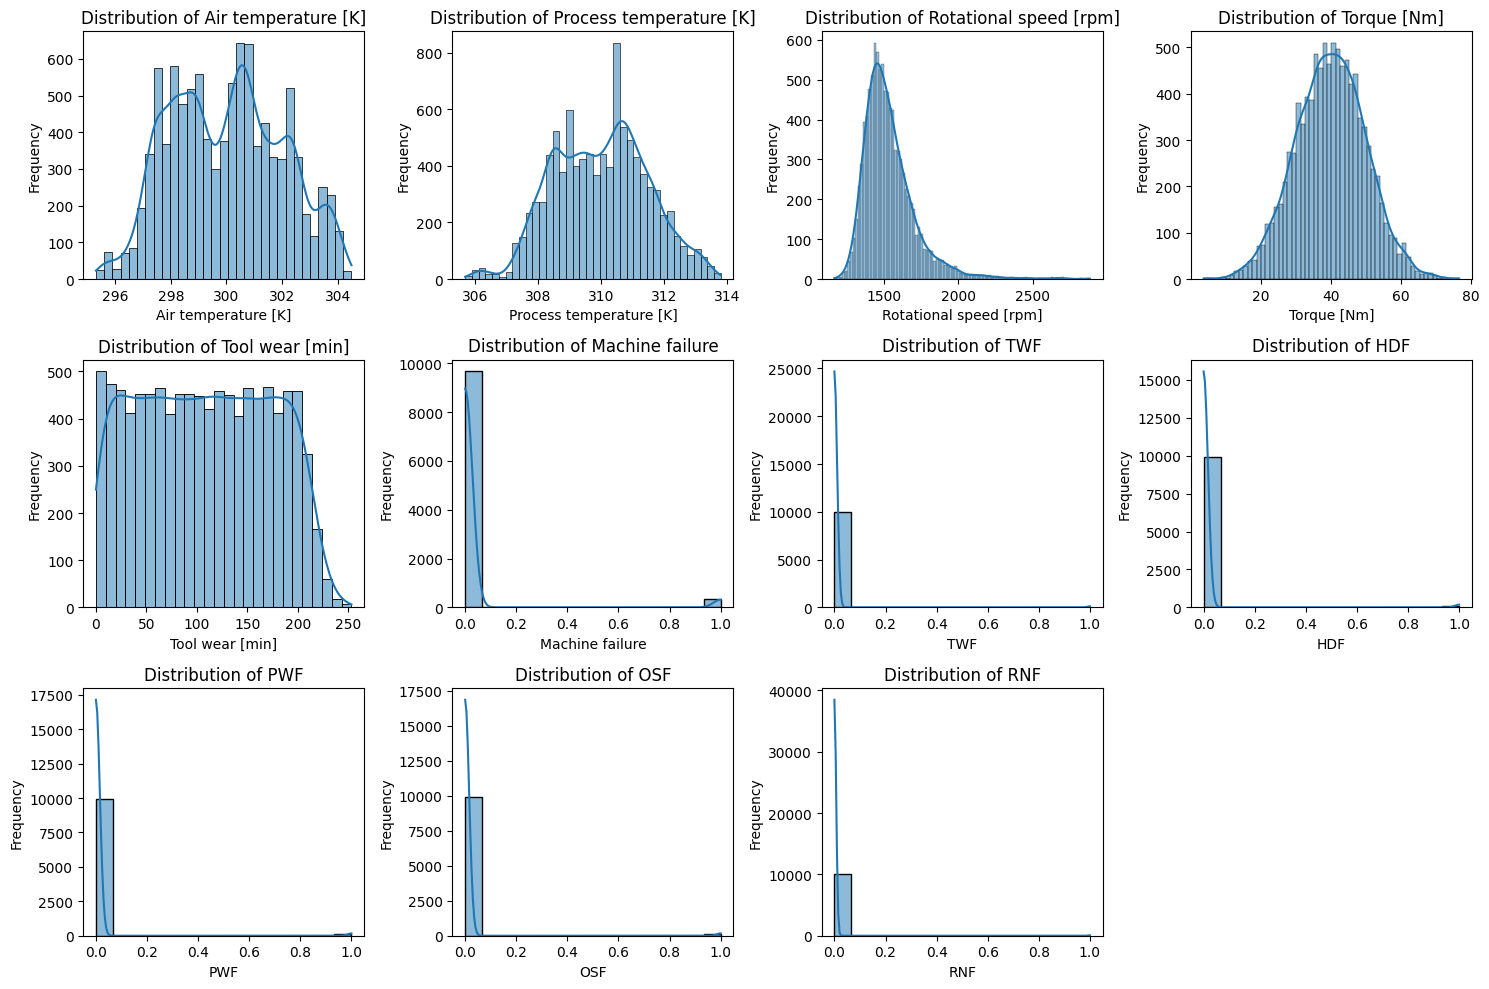

In [ ]:
numerical_features = df.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(3, 4, i + 1) # Adjust subplot grid as needed
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Distribution of Categorical Features

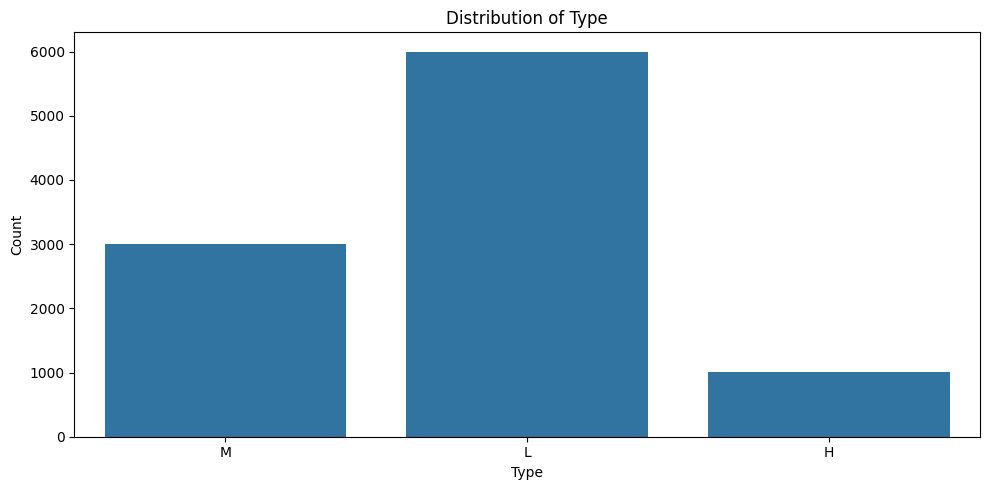

In [ ]:
categorical_features = df.select_dtypes(include=['object']).columns

plt.figure(figsize=(10, 5))
for i, feature in enumerate(categorical_features):
    plt.subplot(1, len(categorical_features), i + 1)
    sns.countplot(x=df[feature])
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Target Imbalance

Machine Failure Counts:
Machine failure
0    9661
1     339
Name: count, dtype: int64

Machine Failure Percentage:
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


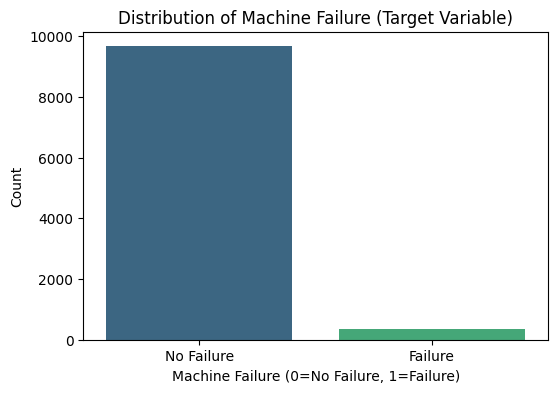

In [ ]:
failure_counts = df['Machine failure'].value_counts()
failure_percentage = df['Machine failure'].value_counts(normalize=True) * 100

print("Machine Failure Counts:")
print(failure_counts)
print("\nMachine Failure Percentage:")
print(failure_percentage)

plt.figure(figsize=(6, 4))
sns.barplot(x=failure_counts.index, y=failure_counts.values, palette='viridis')
plt.title('Distribution of Machine Failure (Target Variable)')
plt.xlabel('Machine Failure (0=No Failure, 1=Failure)')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['No Failure', 'Failure'])
plt.show()

### Feature Distributions: Failed vs. Healthy Machines

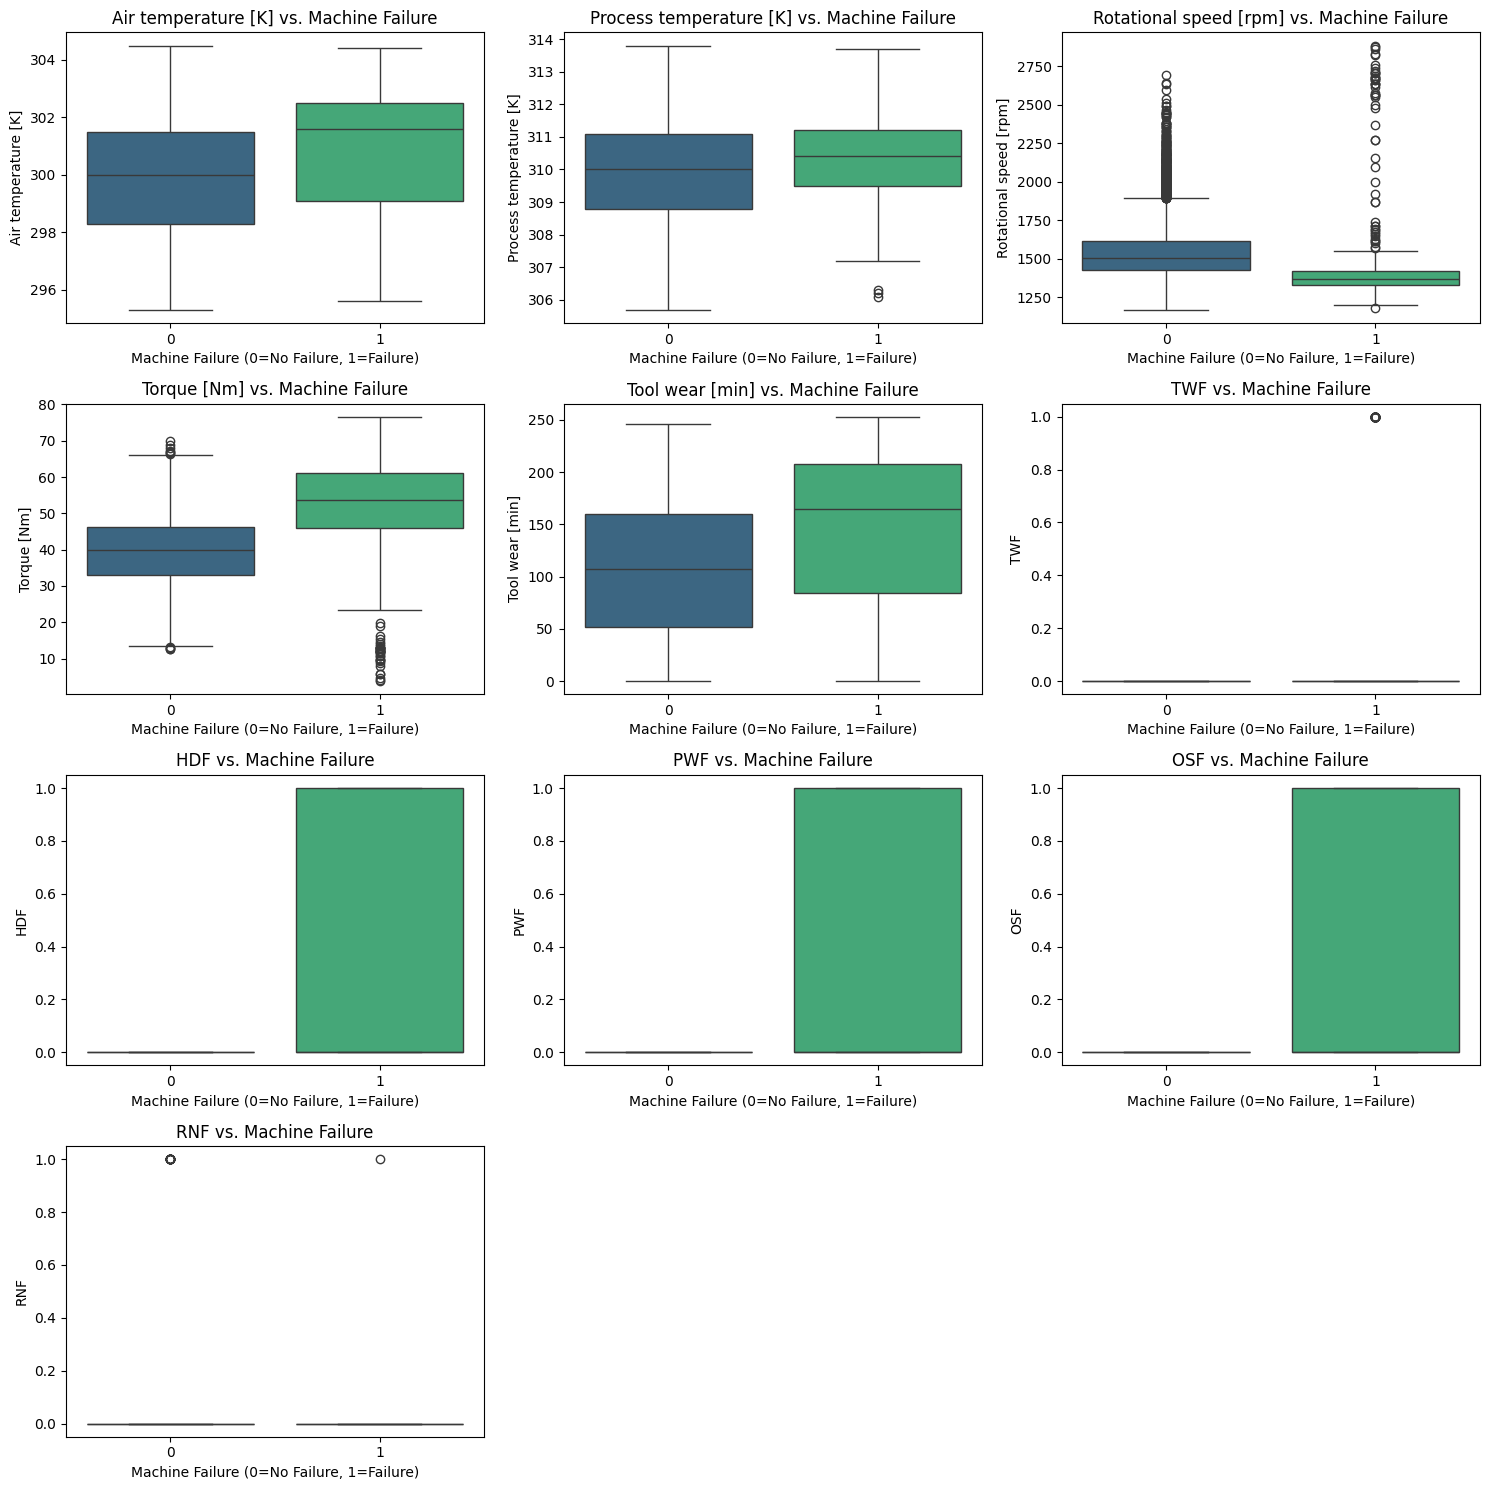

In [ ]:
numerical_features = df.select_dtypes(include=['float64', 'int64']).columns.drop('Machine failure')

plt.figure(figsize=(15, 15))
for i, feature in enumerate(numerical_features):
    plt.subplot(4, 3, i + 1) # Adjust subplot grid as needed
    sns.boxplot(x='Machine failure', y=feature, data=df, palette='viridis')
    plt.title(f'{feature} vs. Machine Failure')
    plt.xlabel('Machine Failure (0=No Failure, 1=Failure)')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()

### Correlation Heatmap

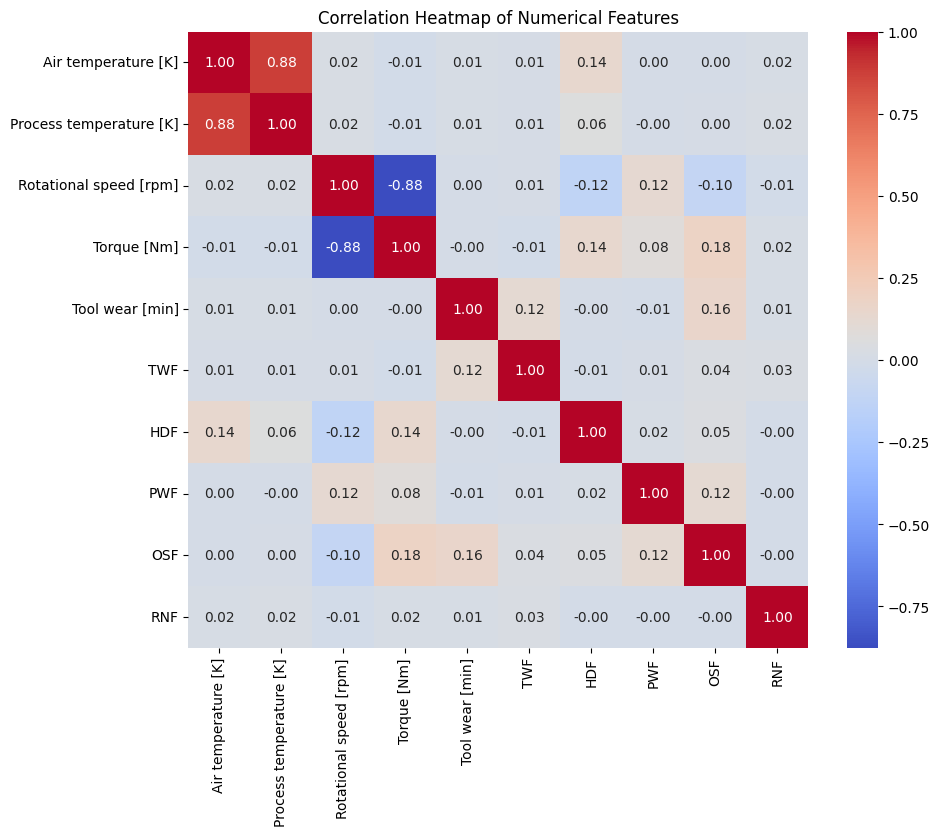

In [ ]:
correlation_matrix = df[numerical_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# Feature engineering

### One-Hot Encoding for Categorical Features

In [ ]:
df = pd.get_dummies(df, columns=['Type'], drop_first=True)
df.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,False,True
1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,True,False
2,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,True,False
3,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,True,False
4,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,True,False


### Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns for scaling (excluding the 'Machine failure' target and one-hot encoded 'Type' columns)
columns_to_scale = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
if 'Machine failure' in columns_to_scale:
    columns_to_scale.remove('Machine failure')
if 'Type_L' in columns_to_scale:
    columns_to_scale.remove('Type_L')
if 'Type_M' in columns_to_scale:
    columns_to_scale.remove('Type_M')

scaler = StandardScaler()
df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])
df.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Type_L,Type_M
0,-0.952389,-0.947360,0.068185,0.282200,-1.695984,0,-0.06798,-0.10786,-0.097934,-0.099484,-0.04363,False,True
1,-0.902393,-0.879959,-0.729472,0.633308,-1.648852,0,-0.06798,-0.10786,-0.097934,-0.099484,-0.04363,True,False
2,-0.952389,-1.014761,-0.227450,0.944290,-1.617430,0,-0.06798,-0.10786,-0.097934,-0.099484,-0.04363,True,False
3,-0.902393,-0.947360,-0.590021,-0.048845,-1.586009,0,-0.06798,-0.10786,-0.097934,-0.099484,-0.04363,True,False
4,-0.902393,-0.879959,-0.729472,0.001313,-1.554588,0,-0.06798,-0.10786,-0.097934,-0.099484,-0.04363,True,False


### Data Splitting

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Machine failure', axis=1)
y = df['Machine failure']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"\nTrain target distribution:\n{y_train.value_counts(normalize=True)}")
print(f"\nTest target distribution:\n{y_test.value_counts(normalize=True)}")

X_train shape: (8000, 12)
X_test shape: (2000, 12)
y_train shape: (8000,)
y_test shape: (2000,)

Train target distribution:
Machine failure
0    0.966125
1    0.033875
Name: proportion, dtype: float64

Test target distribution:
Machine failure
0    0.966
1    0.034
Name: proportion, dtype: float64


# Model Section

# Evaluation:
report precision, recall, ROC-AUC and PR-AUC, not just accuracy. The point you make: in maintenance, catching failures (recall) matters more than overall accuracy.

### Logistic Regression Model Training

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, average_precision_score, confusion_matrix, classification_report

# Initialize and train the Logistic Regression model
# Using a balanced class weight to address the target imbalance
log_reg = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced')
log_reg.fit(X_train, y_train)

# Make predictions on the test set
y_pred_log_reg = log_reg.predict(X_test)
y_proba_log_reg = log_reg.predict_proba(X_test)[:, 1]

### Logistic Regression Model Evaluation

In [ ]:
print("Logistic Regression Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log_reg):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_log_reg):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_log_reg):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_log_reg):.4f}")
print(f"PR-AUC: {average_precision_score(y_test, y_proba_log_reg):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log_reg))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log_reg))

Logistic Regression Model Evaluation:
Accuracy: 0.9990
Precision: 1.0000
Recall: 0.9706
ROC-AUC: 0.9725
PR-AUC: 0.9717

Confusion Matrix:
[[1932    0]
 [   2   66]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



### Random Forest Classifier Model Training

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest Classifier model
# Using a balanced class weight to address the target imbalance
random_forest = RandomForestClassifier(random_state=42, class_weight='balanced')
random_forest.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = random_forest.predict(X_test)
y_proba_rf = random_forest.predict_proba(X_test)[:, 1]

### Random Forest Classifier Model Evaluation

In [ ]:
print("Random Forest Classifier Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")
print(f"PR-AUC: {average_precision_score(y_test, y_proba_rf):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Classifier Model Evaluation:
Accuracy: 0.9985
Precision: 1.0000
Recall: 0.9559
ROC-AUC: 0.9916
PR-AUC: 0.9797

Confusion Matrix:
[[1932    0]
 [   3   65]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.96      0.98        68

    accuracy                           1.00      2000
   macro avg       1.00      0.98      0.99      2000
weighted avg       1.00      1.00      1.00      2000



### Confusion Matrix Visualization for Logistic Regression

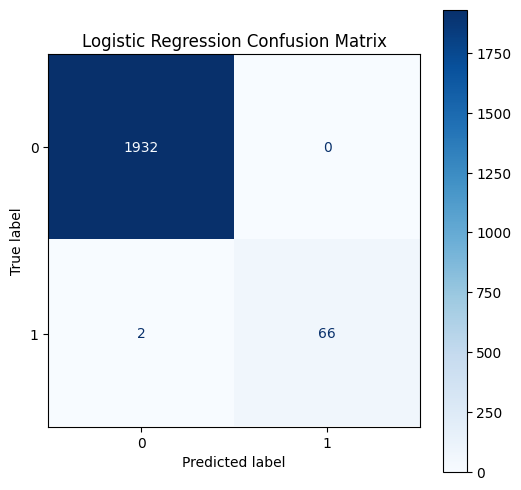

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay

# Plot Confusion Matrix for Logistic Regression
fig_log_reg_cm, ax_log_reg_cm = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(log_reg, X_test, y_test, cmap=plt.cm.Blues, ax=ax_log_reg_cm)
ax_log_reg_cm.set_title('Logistic Regression Confusion Matrix')
plt.show()

### Confusion Matrix Visualization for Random Forest Classifier

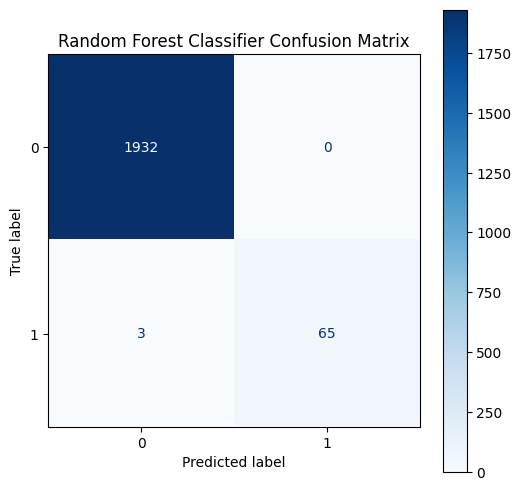

In [37]:
from sklearn.metrics import ConfusionMatrixDisplay

# Plot Confusion Matrix for Random Forest Classifier
fig_rf_cm, ax_rf_cm = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(random_forest, X_test, y_test, cmap=plt.cm.Blues, ax=ax_rf_cm)
ax_rf_cm.set_title('Random Forest Classifier Confusion Matrix')
plt.show()

In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 59.1 MB/s eta 0:00:00


#  **Comparison**:
against a tree model to frame LR as a deliberate interpretable baseline, and add a tiny Streamlit demo or inference script

In [ ]:
# To run this Streamlit app in a local environment:
# 1. Save this code to a Python file (e.g., `app.py`).
# 2. In your terminal, navigate to the directory where you saved `app.py`.
# 3. Make sure Streamlit is installed: `pip install streamlit`
# 4. Run the app using: `streamlit run app.py`

# If you intend to run this in Google Colab directly, you need to install streamlit
# !pip install streamlit

import streamlit as st
import pandas as pd
import numpy as np
import joblib # To save/load model and scaler

# Assuming `log_reg` (Logistic Regression model) and `scaler` (StandardScaler) are already trained and available
# In a real deployment, you would save and load them.

# For demonstration purposes, let's create dummy versions if not available (not recommended for production)
try:
    log_reg_model = log_reg
except NameError:
    st.warning("Logistic Regression model not found. Using a dummy model for demonstration.")
    class DummyModel:
        def predict_proba(self, X):
            return np.random.rand(X.shape[0], 2)
        def predict(self, X):
            return (self.predict_proba(X)[:, 1] > 0.5).astype(int)
    log_reg_model = DummyModel()

try:
    feature_scaler = scaler
except NameError:
    st.warning("Scaler not found. Using a dummy scaler for demonstration.")
    class DummyScaler:
        def transform(self, X):
            return X # No scaling
    feature_scaler = DummyScaler()

# You would typically have a list of features the model expects
# Ensure these match your X_train columns
expected_features = X_train.columns.tolist() # Assuming X_train is available from previous steps

st.title('Machine Failure Prediction App')
st.write('Enter the sensor readings to predict machine failure.')

# Create input fields for each feature
input_data = {}
for feature in expected_features:
    # Determine appropriate input type (number_input for numerical, checkbox for boolean/binary, selectbox for categorical)
    if 'Type_' in feature: # Handle one-hot encoded 'Type' features
        input_data[feature] = st.checkbox(f'{feature.replace("Type_", "Type ")} (True if selected)', value=False)
    elif df[feature].dtype == 'int64' or df[feature].dtype == 'float64':
        # Use min/max from original data for better input range
        min_val = df[feature].min() if feature in df.columns else 0.0
        max_val = df[feature].max() if feature in df.columns else 100.0
        input_data[feature] = st.number_input(f'{feature}', value=(min_val + max_val) / 2.0)
    else:
        input_data[feature] = st.text_input(f'{feature}', '0')

if st.button('Predict Machine Failure'):
    # Convert input data to a DataFrame
    input_df = pd.DataFrame([input_data])

    # Convert boolean 'Type_' columns back to integers (True=1, False=0)
    for col in input_df.columns:
        if 'Type_' in col and input_df[col].dtype == 'bool':
            input_df[col] = input_df[col].astype(int)

    # Ensure the order of columns matches the training data
    input_df = input_df[expected_features]

    # Scale the input features
    scaled_input = feature_scaler.transform(input_df)

    # Make prediction
    prediction_proba = log_reg_model.predict_proba(scaled_input)[:, 1]
    prediction = (prediction_proba > 0.5).astype(int)

    st.subheader('Prediction Result:')
    if prediction[0] == 1:
        st.error(f"The machine is predicted to FAIL with a probability of {prediction_proba[0]:.4f}")
    else:
        st.success(f"The machine is predicted to NOT FAIL with a probability of {prediction_proba[0]:.4f}")

# Instructions on how to run the app
st.sidebar.markdown("""
**How to run this Streamlit app:**
1. Save this code to a Python file (e.g., `app.py`).
2. Open your terminal or command prompt.
3. Navigate to the directory where you saved the file.
4. Run the command: `streamlit run app.py`
""")

2026-06-10 15:58:08.073 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-10 15:58:08.481 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-06-10 15:58:08.485 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-10 15:58:08.488 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-10 15:58:08.490 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-10 15:58:08.493 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-10 15:58:08.496 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-10 15:58:08.503 Thread 'MainThread': mi

DeltaGenerator(_root_container=1, _parent=DeltaGenerator())

### Streamlit Inference Script

### Run Streamlit app using `ngrok` in Colab

In [32]:
# Install ngrok
!pip install pyngrok -q

# Get your authtoken from https://ngrok.com/signup
# Replace 'YOUR_NGROK_AUTH_TOKEN' with your actual token
import os
import time
from pyngrok import ngrok

NGROK_AUTH_TOKEN = '3Ex7E8LC5AunUMIlykxAUgT6G3k_4wmkerUQAYND6wZxtNrrf' # <-- REMEMBER TO REPLACE THIS!
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

# Save your Streamlit app code to a file
streamlit_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import joblib # To save/load model and scaler

# Assuming `log_reg` (Logistic Regression model) and `scaler` (StandardScaler) are already trained and available
# In a real deployment, you would save and load them.

# For demonstration purposes, let's create dummy versions if not available (not recommended for production)
try:
    log_reg_model = log_reg
except NameError:
    st.warning("Logistic Regression model not found. Using a dummy model for demonstration.")
    class DummyModel:
        def predict_proba(self, X):
            return np.random.rand(X.shape[0], 2)
        def predict(self, X):
            return (self.predict_proba(X)[:, 1] > 0.5).astype(int)
    log_reg_model = DummyModel()

try:
    feature_scaler = scaler
except NameError:
    st.warning("Scaler not found. Using a dummy scaler for demonstration.")
    class DummyScaler:
        def transform(self, X):
            return X # No scaling
    feature_scaler = DummyScaler()

# You would typically have a list of features the model expects
# Ensure these match your X_train columns
# Check if X_train exists in the global scope
if 'X_train' in globals():
    expected_features = X_train.columns.tolist()
else:
    # Fallback if X_train is not defined (e.g., if running the app standalone without previous Colab steps)
    # This is a critical point; you should ensure your model is trained and X_train is available
    st.error("X_train not found. Please ensure the model training and data splitting steps are run.")
    expected_features = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Type_L', 'Type_M']

st.title('Machine Failure Prediction App')
st.write('Enter the sensor readings to predict machine failure.')

# Create input fields for each feature
input_data = {}
for feature in expected_features:
    if 'Type_' in feature: # Handle one-hot encoded 'Type' features
        input_data[feature] = st.checkbox(f'{feature.replace("Type_", "Type ")} (True if selected)', value=False)
    else:
        # Attempt to get min/max from df if available, otherwise use defaults
        try:
            min_val = df[feature].min()
            max_val = df[feature].max()
            input_data[feature] = st.number_input(f'{feature}', value=(min_val + max_val) / 2.0)
        except (KeyError, NameError):
            input_data[feature] = st.number_input(f'{feature}', value=0.0)

if st.button('Predict Machine Failure'):
    input_df = pd.DataFrame([input_data])

    for col in input_df.columns:
        if 'Type_' in col and input_df[col].dtype == 'bool':
            input_df[col] = input_df[col].astype(int)

    # Ensure the order of columns matches the training data
    input_df = input_df[expected_features]

    # Scale the input features
    scaled_input = feature_scaler.transform(input_df)

    prediction_proba = log_reg_model.predict_proba(scaled_input)[:, 1]
    prediction = (prediction_proba > 0.5).astype(int)

    st.subheader('Prediction Result:')
    if prediction[0] == 1:
        st.error(f"The machine is predicted to FAIL with a probability of {prediction_proba[0]:.4f}")
    else:
        st.success(f"The machine is predicted to NOT FAIL with a probability of {prediction_proba[0]:.4f}")
'''

with open('app.py', 'w') as f:
    f.write(streamlit_code)

# Start Streamlit in the background
os.system('nohup streamlit run app.py &')

# Give Streamlit some time to start up
time.sleep(5) # You might need to adjust this value if Streamlit takes longer to start

# Connect ngrok to the Streamlit port
public_url = ngrok.connect(addr='8501', proto='http')
print(f"Streamlit App URL: {public_url}")

Streamlit App URL: NgrokTunnel: "https://skittle-rubdown-clarity.ngrok-free.dev" -> "http://localhost:8501"


Comaprison with Random forest Classifier

## Cross-Validation

Cross-validation is a technique used to assess how the results of a statistical analysis will generalize to an independent data set. It is mainly used in settings where the goal is prediction, and one wants to estimate how accurately a predictive model will perform in practice. In this case, we will use Stratified K-Fold cross-validation due to the imbalanced nature of our target variable (`Machine failure`).

In [39]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Define the cross-validation strategy
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### Cross-Validation for Logistic Regression

In [40]:
# Evaluate Logistic Regression using cross-validation
print("Logistic Regression Cross-Validation Results:")

accuracy_scores_lr = cross_val_score(log_reg, X, y, cv=skf, scoring='accuracy')
precision_scores_lr = cross_val_score(log_reg, X, y, cv=skf, scoring='precision')
recall_scores_lr = cross_val_score(log_reg, X, y, cv=skf, scoring='recall')
roc_auc_scores_lr = cross_val_score(log_reg, X, y, cv=skf, scoring='roc_auc')

print(f"Mean Accuracy: {accuracy_scores_lr.mean():.4f} (Std: {accuracy_scores_lr.std():.4f})")
print(f"Mean Precision: {precision_scores_lr.mean():.4f} (Std: {precision_scores_lr.std():.4f})")
print(f"Mean Recall: {recall_scores_lr.mean():.4f} (Std: {recall_scores_lr.std():.4f})")
print(f"Mean ROC-AUC: {roc_auc_scores_lr.mean():.4f} (Std: {roc_auc_scores_lr.std():.4f})")

Logistic Regression Cross-Validation Results:
Mean Accuracy: 0.9991 (Std: 0.0002)
Mean Precision: 1.0000 (Std: 0.0000)
Mean Recall: 0.9734 (Std: 0.0059)
Mean ROC-AUC: 0.9815 (Std: 0.0043)


### Cross-Validation for Random Forest Classifier

In [41]:
# Evaluate Random Forest using cross-validation
print("Random Forest Classifier Cross-Validation Results:")

accuracy_scores_rf = cross_val_score(rf, X, y, cv=skf, scoring='accuracy')
precision_scores_rf = cross_val_score(rf, X, y, cv=skf, scoring='precision')
recall_scores_rf = cross_val_score(rf, X, y, cv=skf, scoring='recall')
roc_auc_scores_rf = cross_val_score(rf, X, y, cv=skf, scoring='roc_auc')

print(f"Mean Accuracy: {accuracy_scores_rf.mean():.4f} (Std: {accuracy_scores_rf.std():.4f})")
print(f"Mean Precision: {precision_scores_rf.mean():.4f} (Std: {precision_scores_rf.std():.4f})")
print(f"Mean Recall: {recall_scores_rf.mean():.4f} (Std: {recall_scores_rf.std():.4f})")
print(f"Mean ROC-AUC: {roc_auc_scores_rf.mean():.4f} (Std: {roc_auc_scores_rf.std():.4f})")

Random Forest Classifier Cross-Validation Results:
Mean Accuracy: 0.9990 (Std: 0.0000)
Mean Precision: 1.0000 (Std: 0.0000)
Mean Recall: 0.9705 (Std: 0.0002)
Mean ROC-AUC: 0.9868 (Std: 0.0030)


### Cross-Validation for XGBoost Classifier

In [54]:
# Evaluate XGBoost using cross-validation
# Need to sanitize the full X dataset for cross-validation as well
import re

def sanitize_col_names_for_full_X(df):
    cols = df.columns
    new_cols = []
    for col in cols:
        new_col = re.sub(r'[^A-Za-z0-9_]+', '', col) # Remove special characters
        new_cols.append(new_col)
    df.columns = new_cols
    return df

X_sanitized = X.copy()
X_sanitized = sanitize_col_names_for_full_X(X_sanitized)

print("XGBoost Classifier Cross-Validation Results:")

accuracy_scores_xgb = cross_val_score(xgb_model, X_sanitized, y, cv=skf, scoring='accuracy')
precision_scores_xgb = cross_val_score(xgb_model, X_sanitized, y, cv=skf, scoring='precision')
recall_scores_xgb = cross_val_score(xgb_model, X_sanitized, y, cv=skf, scoring='recall')
roc_auc_scores_xgb = cross_val_score(xgb_model, X_sanitized, y, cv=skf, scoring='roc_auc')

print(f"Mean Accuracy: {accuracy_scores_xgb.mean():.4f} (Std: {accuracy_scores_xgb.std():.4f})")
print(f"Mean Precision: {precision_scores_xgb.mean():.4f} (Std: {precision_scores_xgb.std():.4f})")
print(f"Mean Recall: {recall_scores_xgb.mean():.4f} (Std: {recall_scores_xgb.std():.4f})")
print(f"Mean ROC-AUC: {roc_auc_scores_xgb.mean():.4f} (Std: {roc_auc_scores_xgb.std():.4f})")

XGBoost Classifier Cross-Validation Results:
Mean Accuracy: 0.9989 (Std: 0.0005)
Mean Precision: 0.9940 (Std: 0.0119)
Mean Recall: 0.9734 (Std: 0.0059)
Mean ROC-AUC: 0.9925 (Std: 0.0038)


In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize a Random Forest Classifier with parameters to reduce overfitting
# max_depth limits the depth of each tree
# min_samples_leaf ensures each leaf has a minimum number of samples
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10, min_samples_leaf=5, class_weight='balanced')

rf.fit(X_train, y_train)

predictions = rf.predict(X_test)

print("Random Forest Classifier Evaluation (with adjusted parameters):")
print(f"Accuracy: {accuracy_score(y_test, predictions):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, predictions))

Random Forest Classifier Evaluation (with adjusted parameters):
Accuracy: 0.9990

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



### XGBoost Classifier

XGBoost (eXtreme Gradient Boosting) is an optimized distributed gradient boosting library designed to be highly efficient, flexible, and portable. It implements machine learning algorithms under the Gradient Boosting framework. XGBoost provides a parallel tree boosting (also known as GBDT, GBM) that solves many data science problems in a fast and accurate way.

Key features include:
-   **Scalability**: Runs on a single machine or distributed systems.
-   **Efficiency**: Optimized algorithms and parallelization.
-   **Flexibility**: Supports various objective functions and evaluation metrics.
-   **Regularization**: Includes L1 and L2 regularization to prevent overfitting.
-   **Handling Missing Values**: Has a default way to handle sparse data.

Given its power and common use in predictive modeling, it's a great candidate for our machine failure prediction task, especially with the imbalanced dataset.

In [48]:
# Install XGBoost if not already installed

import xgboost as xgb

### XGBoost Classifier Model Training

In [53]:
from xgboost import XGBClassifier
import re

# Sanitize column names for XGBoost compatibility
def sanitize_col_names(df):
    cols = df.columns
    new_cols = []
    for col in cols:
        new_col = re.sub(r'[^A-Za-z0-9_]+', '', col) # Remove special characters
        new_cols.append(new_col)
    df.columns = new_cols
    return df

X_train_sanitized = X_train.copy()
X_test_sanitized = X_test.copy()

X_train_sanitized = sanitize_col_names(X_train_sanitized)
X_test_sanitized = sanitize_col_names(X_test_sanitized)

# Calculate scale_pos_weight for handling class imbalance
# This is (count of negative examples) / (count of positive examples)
scale_pos_weight_value = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# Initialize and train the XGBoost Classifier model
# We use scale_pos_weight to address the target imbalance
xgb_model = XGBClassifier(
    objective='binary:logistic', # For binary classification
    eval_metric='logloss',       # Evaluation metric
    use_label_encoder=False,     # Suppress warning about deprecated use_label_encoder
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,                 # Limit tree depth to prevent overfitting
    subsample=0.8,               # Fraction of samples to be used for fitting the individual base learners
    colsample_bytree=0.8,        # Fraction of features to be used for fitting the individual base learners
    gamma=0.1,                   # Minimum loss reduction required to make a further partition on a leaf node
    scale_pos_weight=scale_pos_weight_value # Handle class imbalance
)
xgb_model.fit(X_train_sanitized, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test_sanitized)
y_proba_xgb = xgb_model.predict_proba(X_test_sanitized)[:, 1]

### XGBoost Classifier Model Evaluation

In [51]:
print("XGBoost Classifier Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_xgb):.4f}")
print(f"PR-AUC: {average_precision_score(y_test, y_proba_xgb):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Classifier Model Evaluation:
Accuracy: 0.9990
Precision: 1.0000
Recall: 0.9706
ROC-AUC: 0.9918
PR-AUC: 0.9759

Confusion Matrix:
[[1932    0]
 [   2   66]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



### Confusion Matrix Visualization for XGBoost Classifier

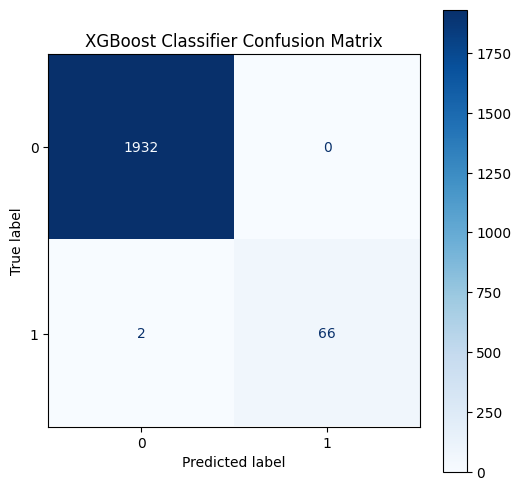

In [55]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Plot Confusion Matrix for XGBoost Classifier
fig_xgb_cm, ax_xgb_cm = plt.subplots(figsize=(6, 6))
# Ensure X_test is sanitized before passing to ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(xgb_model, X_test_sanitized, y_test, cmap=plt.cm.Blues, ax=ax_xgb_cm)
ax_xgb_cm.set_title('XGBoost Classifier Confusion Matrix')
plt.show()